# Multimodal Tweet Classification with Cross-Attention

This notebook implements a cross-attention based model for multimodal tweet classification, combining text and image features for better prediction accuracy.

In [1]:
#  informative_Attention_graph_V2

In [2]:
cd 

/root


In [3]:
cd /kaggle

/kaggle


In [4]:
cd input/datasets/jaychangani/required-libraries

/kaggle/input/datasets/jaychangani/required-libraries


In [5]:
pwd

'/kaggle/input/datasets/jaychangani/required-libraries'

In [6]:
# Import required libraries

from exp.Required_Modules_And_Packages import *
from exp.Data_Reading_And_Preprocessing_CrisisMMD_V2 import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from torchvision.models import resnet50
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
import numpy as np
from tqdm import tqdm
import torch.multiprocessing as mp
import random
from sklearn.metrics import classification_report

# Set multiprocessing method
if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)

# Set device and random seeds for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
print(f"Using device: {device}")

/kaggle/input/datasets/jaychangani/required-libraries/exp/external/aidrtokenize.py:50: SyntaxWarning: invalid escape sequence '\w'
  Contractions = re.compile("(?i)(\w+)(n['’′]t|['’′]ve|['’′]ll|['’′]d|['’′]re|['’′]s|['’′]m)$", re.UNICODE)
/kaggle/input/datasets/jaychangani/required-libraries/exp/external/aidrtokenize.py:51: SyntaxWarning: invalid escape sequence '\s'
  Whitespace = re.compile("[\s\u0020\u00a0\u1680\u180e\u202f\u205f\u3000\u2000-\u200a]+", re.UNICODE)
/kaggle/input/datasets/jaychangani/required-libraries/exp/external/aidrtokenize.py:176: SyntaxWarning: invalid escape sequence '\W'
  Email = regex_or("(?<=(?:\W))", "(?<=(?:^))") + r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,4}(?=" + Bound + ")"
/kaggle/input/datasets/jaychangani/required-libraries/exp/external/aidrtokenize.py:304: SyntaxWarning: invalid escape sequence '\['
  punc = "[#(),$%^&*+={}\[\]:\"|\~`<>/,¦!?½£¶¼©⅐⅑⅒⅓⅔⅕⅖⅗⅘⅙⅚⅛⅜⅝⅞⅟↉¤¿º;-]+"
/kaggle/input/datasets/jaychangani/required-libraries/exp/external/aidr

Using device: cuda


## 1. Data Loading and Preprocessing

In [7]:
# Get tsv files for informative task
train_tsv, dev_tsv, test_tsv, info = get_tsv_data_files('Informativeness_task_tsv_files')

# Load and preprocess data
path = Path('/kaggle/input/')
data_info_text_image, test_data_info_text_image = get_dataframe(
    train_tsv, dev_tsv, test_tsv, info, path,
    validate_images=False  # skip image validation until paths are confirmed
)

vc = data_info_text_image['is_valid'].value_counts()

print(f"shape of data: {data_info_text_image.shape}\n")
print(f"train set: {vc.get(False, 0)}")
print(f"valid set: {vc.get(True, 0)}")
print("=" * 50)
print(f"shape of test data: {test_data_info_text_image.shape}\n")

reading data and preprocessing it.....
[train] shape=(13607, 9)
[train] columns=['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image']
[Row cleaning] removed=0 kept=13607 (min_tokens=2)
[Duplicate removal] subset=both removed=0 kept=13607
[train] avg_token_count=13.22 | median_token_count=13.00
[train] label_text distribution:
label_text
informative        9637
not_informative    3970
Name: count, dtype: int64
[train] label_image distribution:
label_image
informative        7058
not_informative    6549
Name: count, dtype: int64
[dev] shape=(2237, 9)
[dev] columns=['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image']
[Row cleaning] removed=0 kept=2237 (min_tokens=2)
[Duplicate removal] subset=both removed=0 kept=2237
[dev] avg_token_count=13.19 | median_token_count=13.00
[dev] label_text distribution:
label_text
informative        1612
not_informative     62

In [8]:
# Get number of unique labels from the data
num_labels = len(data_info_text_image['label_text'].unique())
model_path = "/kaggle/input/datasets/jaychangani/local-model/bert_local"

print(f"Number of unique labels: {num_labels}")
print(f"Using BERT model from: {model_path}")

Number of unique labels: 2
Using BERT model from: /kaggle/input/datasets/jaychangani/local-model/bert_local


## 2. Improved Model Architecture

**Changes from v1:** 
- Dropout increased from 0.1→0.3 in cross-attention, 0.2→0.4 in classifier
- Added FFN (Feed-Forward Network) blocks after cross-attention with residual connections
- Added post-fusion LayerNorm before classifier head
- Label smoothing (0.1) in loss to reduce overconfidence

In [9]:
class BidirectionalCrossAttentionBlock(nn.Module):
    """
    Bidirectional cross-attention block with FFN sublayer.
    Changes vs v1:
      - dropout raised to 0.3 (was 0.1)
      - added FFN sublayer (expand=2) with residual + LayerNorm after attention
    """

    def __init__(self, d_model=512, num_heads=8, dropout=0.3, ffn_expand=2):
        super().__init__()
        # Pre-norm (attention sublayer)
        self.text_norm  = nn.LayerNorm(d_model)
        self.image_norm = nn.LayerNorm(d_model)

        self.text_to_image_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.image_to_text_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.text_drop  = nn.Dropout(dropout)
        self.image_drop = nn.Dropout(dropout)

        # FFN sublayer for text
        ffn_dim = d_model * ffn_expand
        self.text_ffn = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )
        # FFN sublayer for image
        self.image_ffn = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, text_seq, image_seq):
        # ---- Attention sublayer ----
        text_in  = self.text_norm(text_seq)
        image_in = self.image_norm(image_seq)

        text_attended,  _ = self.text_to_image_attn(
            query=text_in,  key=image_in, value=image_in)
        image_attended, _ = self.image_to_text_attn(
            query=image_in, key=text_in,  value=text_in)

        text_out  = text_seq  + self.text_drop(text_attended)
        image_out = image_seq + self.image_drop(image_attended)

        # ---- FFN sublayer (with residual) ----
        text_out  = text_out  + self.text_ffn(text_out)
        image_out = image_out + self.image_ffn(image_out)

        return text_out, image_out


class MultimodalClassifier(nn.Module):
    """
    Multimodal classifier v2 (anti-overfitting):
      1) Full text + image sequences → bidirectional cross-attention (with FFN)
      2) Strong fusion: [text_cls, image_cls, text_cls * image_cls]
      3) Post-fusion LayerNorm before classifier head
      4) Classifier: 1536→512→256→num_classes with dropout=0.4
    """

    def __init__(
        self,
        d_model=512,
        num_heads=8,
        num_classes=2,
        bert_model=None,
        dropout=0.4,           # increased from 0.2
        attn_dropout=0.3,      # increased from 0.1
    ):
        super().__init__()

        # Image backbone (ResNet50 without avgpool/fc → spatial map)
        base_resnet = resnet50(pretrained=True)
        self.image_backbone = nn.Sequential(*list(base_resnet.children())[:-2])

        # Text encoder (BERT)
        self.text_encoder = bert_model if bert_model is not None             else AutoModel.from_pretrained('bert-base-uncased')

        # Projection + pre-norms
        self.image_pre_norm  = nn.LayerNorm(2048)
        self.text_pre_norm   = nn.LayerNorm(768)
        self.image_projection = nn.Linear(2048, d_model)
        self.text_projection  = nn.Linear(768,  d_model)

        # Bidirectional cross-attention block (with FFN)
        self.cross_block = BidirectionalCrossAttentionBlock(
            d_model=d_model,
            num_heads=num_heads,
            dropout=attn_dropout,
        )

        # Post-fusion LayerNorm (new)
        fusion_dim = d_model * 3      # 1536
        self.fusion_norm = nn.LayerNorm(fusion_dim)

        # Classifier head with higher dropout
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, images, input_ids, attention_mask):
        # Text features
        text_outputs = self.text_encoder(
            input_ids=input_ids, attention_mask=attention_mask)
        text_seq_raw = (text_outputs[0] if isinstance(text_outputs, tuple)
                        else text_outputs.last_hidden_state)
        text_seq = self.text_projection(self.text_pre_norm(text_seq_raw))

        # Image features
        feat_map = self.image_backbone(images)
        bsz, ch, hf, wf = feat_map.shape
        image_seq_raw = feat_map.flatten(2).transpose(1, 2)   # (B, N, 2048)
        image_seq = self.image_projection(self.image_pre_norm(image_seq_raw))

        # Bidirectional cross-attention
        text_attended, image_attended = self.cross_block(text_seq, image_seq)

        # Pool
        text_cls  = text_attended[:, 0, :]          # CLS token
        image_cls = image_attended.mean(dim=1)       # patch mean

        # Fusion
        interaction = text_cls * image_cls
        fused = torch.cat([text_cls, image_cls, interaction], dim=-1)
        fused = self.fusion_norm(fused)              # new: normalize before head

        return self.classifier(fused)


In [10]:
# Get number of unique labels from the data
num_labels = len(data_info_text_image['label_text'].unique())
model_path = "/kaggle/input/datasets/jaychangani/local-model/bert_local"

print(f"Number of unique labels: {num_labels}")
print(f"Using BERT model from: {model_path}")

Number of unique labels: 2
Using BERT model from: /kaggle/input/datasets/jaychangani/local-model/bert_local


## 3. Dataset and DataLoader

## 3. Dataset with Image Augmentation

**Changes:** Training set now uses `RandomHorizontalFlip`, `RandomCrop`, and `ColorJitter` — this acts as regularization on the image modality.

In [11]:
class MultimodalDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, image_path, transform=None):
        self.df = df
        self.tokenizer = tokenizer
        self.image_path = image_path
        self.transform = transform
        self.label_map = {'not_informative': 0, 'informative': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            text = str(row['tweet_text'])
            image_path = self.image_path / row['image']

            encoding = self.tokenizer(
                text,
                add_special_tokens=True,
                max_length=128,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors=None,
            )

            image = Image.open(image_path).convert('RGB')
            if self.transform:
                image = self.transform(image)

            label      = torch.tensor(self.label_map[row['label_text']], dtype=torch.long)
            input_ids  = torch.tensor(encoding['input_ids'],      dtype=torch.long)
            attn_mask  = torch.tensor(encoding['attention_mask'], dtype=torch.long)

        except Exception as e:
            print(f"Error at idx {idx}: {e}")
            raise

        return {'image': image, 'input_ids': input_ids,
                'attention_mask': attn_mask, 'label': label}


# ── Transforms ───────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training: augmentation acts as image-side regularization
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),                          # random spatial crop
    transforms.RandomHorizontalFlip(p=0.5),              # flip
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.05),    # colour jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation/Test: deterministic centre-crop
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Tokenizer ────────────────────────────────────────────────────────────────
print("Loading tokenizer...")
try:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    print("Tokenizer loaded.")
except Exception as e:
    print(f"Fallback to bert-base-uncased: {e}")
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# ── DataLoaders ──────────────────────────────────────────────────────────────
image_path = Path('/kaggle/input/datasets/mohammadabdulbasit/crisismmd/CrisisMMD_v2.0/')

train_df = data_info_text_image[~data_info_text_image['is_valid']]
val_df   = data_info_text_image[data_info_text_image['is_valid']]
test_df  = test_data_info_text_image

train_dataset = MultimodalDataset(train_df, tokenizer, image_path, train_transform)
val_dataset   = MultimodalDataset(val_df,   tokenizer, image_path, val_transform)
test_dataset  = MultimodalDataset(test_df,  tokenizer, image_path, val_transform)

# In notebooks, keep workers at 0 to avoid spawn/pickle issues with local classes
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Loading tokenizer...
Tokenizer loaded.
Train: 13607, Val: 2237, Test: 2237


## 4. Training and Evaluation Functions

## 4. Improved Training & Evaluation Functions

**Changes:** Gradient clipping (`max_norm=1.0`) added to prevent gradient explosions.

In [12]:
def train_epoch(model, train_loader, criterion, optimizer, device,
               grad_clip=1.0, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader, desc='Training', leave=True):
        images        = batch['image'].to(device)
        input_ids     = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels        = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask)
        loss    = criterion(outputs, labels)
        loss.backward()

        # ── Gradient clipping (new) ──────────────────────────────────────
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

        optimizer.step()
        if scheduler is not None and hasattr(scheduler, 'step_batch'):
            scheduler.step()   # for per-step schedulers

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(train_loader), 100. * correct / total


def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Evaluating', leave=True):
            images        = batch['image'].to(device)
            input_ids     = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels        = batch['label'].to(device)

            outputs = model(images, input_ids, attention_mask)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds,
          target_names=['not_informative', 'informative']))

    return total_loss / len(val_loader), 100. * correct / total


## 5. Model Training

## 5. Model Training (Improved)

**Key changes vs original:**
| What | Original | Improved |
|---|---|---|
| Dropout (attention) | 0.1 | **0.3** |
| Dropout (classifier) | 0.2 | **0.4** |
| Weight decay (AdamW) | 0 | **1e-4** |
| Loss | CrossEntropy | **CrossEntropy + label_smoothing=0.1** |
| Gradient clipping | ✗ | **✓ (max_norm=1.0)** |
| Image augmentation | ✗ | **✓ (crop, flip, colour jitter)** |
| FFN after attention | ✗ | **✓** |
| Post-fusion norm | ✗ | **✓** |
| Early stopping | ✗ | **✓ (patience=3)** |
| LR scheduler | CosineAnnealing | **Warmup + CosineAnnealing** |


In [13]:
# ── Load BERT ─────────────────────────────────────────────────────────────
print("Loading BERT...")
try:
    tokenizer  = AutoTokenizer.from_pretrained(model_path)
    bert_model = AutoModel.from_pretrained(model_path)
    print("BERT loaded.")
except Exception as e:
    print(f"Error: {e}"); raise

# ── Model ─────────────────────────────────────────────────────────────────
model = MultimodalClassifier(
    bert_model=bert_model,
    num_classes=num_labels,
    dropout=0.4,        # classifier dropout
    attn_dropout=0.3,   # cross-attention dropout
).to(device)
model.text_encoder.train()

# ── Loss: label smoothing reduces overconfidence on training set ──────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Optimizer with weight decay ───────────────────────────────────────────
optimizer = AdamW([
    {'params': model.image_backbone.parameters(),  'lr': 1e-5,  'weight_decay': 1e-4},
    {'params': model.text_encoder.parameters(),    'lr': 2e-6,  'weight_decay': 1e-4},
    {'params': (list(model.image_projection.parameters()) +
               list(model.text_projection.parameters()) +
               list(model.image_pre_norm.parameters()) +
               list(model.text_pre_norm.parameters()) +
               list(model.fusion_norm.parameters()) +
               list(model.cross_block.parameters()) +
               list(model.classifier.parameters())),
     'lr': 2e-5, 'weight_decay': 1e-4},
])

# ── LR Scheduler: linear warmup → cosine decay ───────────────────────────
num_epochs   = 10          # more epochs because early stopping guards us
warmup_steps = len(train_loader)   # 1 epoch warm-up
total_steps  = num_epochs * len(train_loader)

from torch.optim.lr_scheduler import (
    LinearLR, CosineAnnealingLR, SequentialLR
)
warmup_sched  = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                          total_iters=warmup_steps)
cosine_sched  = CosineAnnealingLR(optimizer, T_max=total_steps - warmup_steps,
                                   eta_min=1e-7)
scheduler = SequentialLR(optimizer,
                         schedulers=[warmup_sched, cosine_sched],
                         milestones=[warmup_steps])

# ── Training loop with early stopping ─────────────────────────────────────
best_val_acc  = 0.0
patience      = 3          # stop if val_acc doesn't improve for 3 epochs
patience_ctr  = 0
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []
SAVE_PATH = '/kaggle/working/informative_Attention_graph_V2_improved.pth'

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 40)

    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device, grad_clip=1.0)
    val_loss,   val_acc   = evaluate(
        model, val_loader,   criterion, device)

    scheduler.step()  # step cosine scheduler per epoch after warmup

    train_losses.append(train_loss); train_accs.append(train_acc)
    val_losses.append(val_loss);     val_accs.append(val_acc)

    print(f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%')
    print(f'Val   Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_ctr = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  ✓ Best model saved (val_acc={val_acc:.2f}%)')
    else:
        patience_ctr += 1
        print(f'  ✗ No improvement ({patience_ctr}/{patience})')
        if patience_ctr >= patience:
            print(f'Early stopping triggered after epoch {epoch+1}.')
            break

print(f'\nTraining complete. Best val acc: {best_val_acc:.2f}%')


Loading BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/datasets/jaychangani/local-model/bert_local
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


BERT loaded.
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s] 


...


Classification Report:
                 precision    recall  f1-score   support

not_informative       0.75      0.61      0.67       625
    informative       0.86      0.92      0.89      1612

       accuracy                           0.83      2237
      macro avg       0.80      0.76      0.78      2237
   weighted avg       0.83      0.83      0.83      2237

Train Loss: 0.4256  Acc: 85.78%
Val   Loss: 0.4635  Acc: 83.33%
  ✓ Best model saved (val_acc=83.33%)

Epoch 9/10
----------------------------------------


Training:  28%|██▊       | 238/851 [03:19<08:33,  1.19it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 70/70 [00:44<00:00,  1.56it/s]



Classification Report:
                 precision    recall  f1-score   support

not_informative       0.75      0.58      0.66       625
    informative       0.85      0.92      0.89      1612

       accuracy                           0.83      2237
      macro avg       0.80      0.75      0.77      2237
   weighted avg       0.82      0.83      0.82      2237

Train Loss: 0.4215  Acc: 86.10%
Val   Loss: 0.4602  Acc: 82.88%
  ✗ No improvement (1/3)

Epoch 10/10
----------------------------------------


Training:  32%|███▏      | 272/851 [03:48<08:14,  1.17it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 70/70 [00:44<00:00,  1.58it/s]



Classification Report:
                 precision    recall  f1-score   support

not_informative       0.77      0.59      0.66       625
    informative       0.85      0.93      0.89      1612

       accuracy                           0.83      2237
      macro avg       0.81      0.76      0.78      2237
   weighted avg       0.83      0.83      0.83      2237

Train Loss: 0.4127  Acc: 86.68%
Val   Loss: 0.4645  Acc: 83.42%
  ✓ Best model saved (val_acc=83.42%)

Training complete. Best val acc: 83.42%


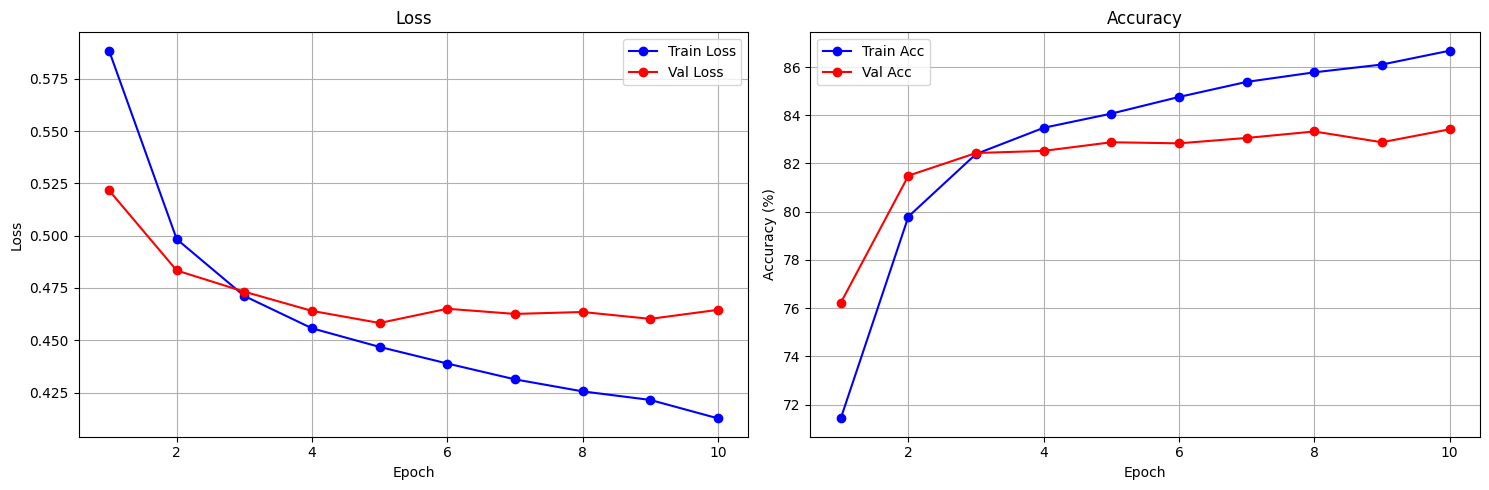


Training history:
  Epoch  1: Train 71.43% / 0.5885  |  Val 76.22% / 0.5217
  Epoch  2: Train 79.80% / 0.4983  |  Val 81.49% / 0.4834
  Epoch  3: Train 82.39% / 0.4712  |  Val 82.43% / 0.4732
  Epoch  4: Train 83.48% / 0.4557  |  Val 82.52% / 0.4640
  Epoch  5: Train 84.07% / 0.4468  |  Val 82.88% / 0.4583
  Epoch  6: Train 84.76% / 0.4389  |  Val 82.83% / 0.4651
  Epoch  7: Train 85.38% / 0.4313  |  Val 83.06% / 0.4626
  Epoch  8: Train 85.78% / 0.4256  |  Val 83.33% / 0.4635
  Epoch  9: Train 86.10% / 0.4215  |  Val 82.88% / 0.4602
  Epoch 10: Train 86.68% / 0.4127  |  Val 83.42% / 0.4645


In [14]:
# ── Plot training curves ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

epochs_ran = range(1, len(train_losses) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epochs_ran, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs_ran, val_losses,   'r-o', label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs_ran, train_accs, 'b-o', label='Train Acc')
ax2.plot(epochs_ran, val_accs,   'r-o', label='Val Acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_improved.png', dpi=120)
plt.show()

print("\nTraining history:")
for ep, (tl,ta,vl,va) in enumerate(zip(train_losses,train_accs,val_losses,val_accs), 1):
    print(f"  Epoch {ep:2d}: Train {ta:.2f}% / {tl:.4f}  |  Val {va:.2f}% / {vl:.4f}")


In [15]:
# ── Test evaluation ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%')


Evaluating:   0%|          | 0/70 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 70/70 [01:03<00:00,  1.10it/s]


Classification Report:
                 precision    recall  f1-score   support

not_informative       0.78      0.61      0.68       625
    informative       0.86      0.93      0.90      1612

       accuracy                           0.84      2237
      macro avg       0.82      0.77      0.79      2237
   weighted avg       0.84      0.84      0.84      2237

Test Loss: 0.4590  Acc: 84.26%


Getting test set predictions...


Getting predictions:   0%|          | 0/70 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Getting predictions: 100%|██████████| 70/70 [00:43<00:00,  1.60it/s]


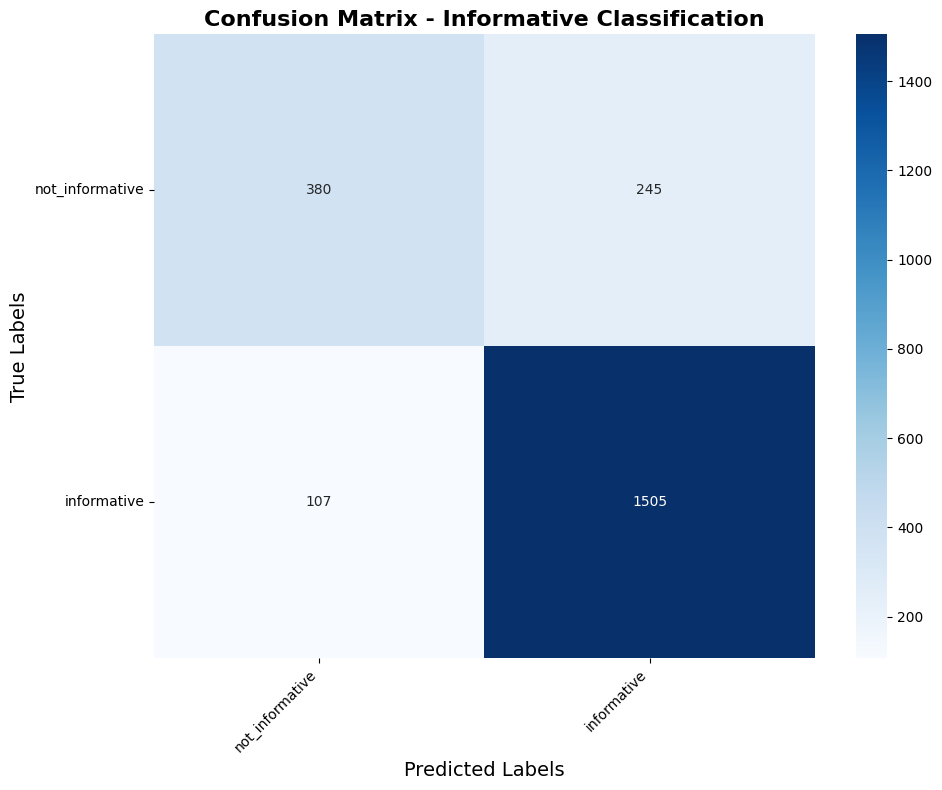

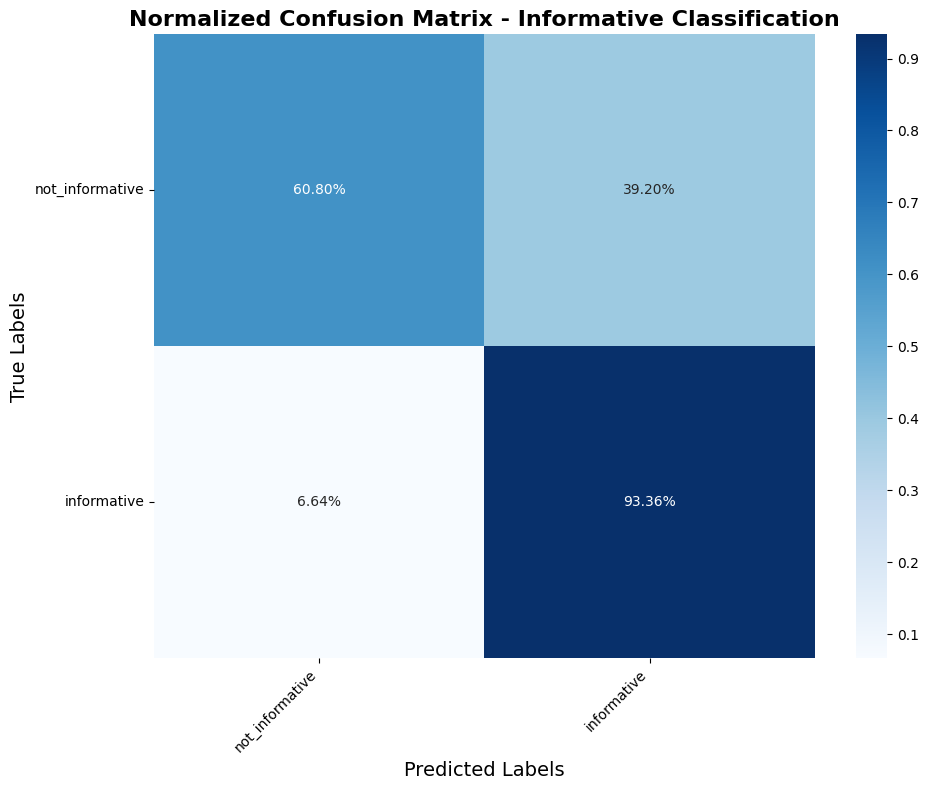


DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

not_informative     0.7803    0.6080    0.6835       625
    informative     0.8600    0.9336    0.8953      1612

       accuracy                         0.8426      2237
      macro avg     0.8201    0.7708    0.7894      2237
   weighted avg     0.8377    0.8426    0.8361      2237


PER-CLASS ACCURACY ANALYSIS
not_informative          : 0.6080 (380/625 samples)
informative              : 0.9336 (1505/1612 samples)


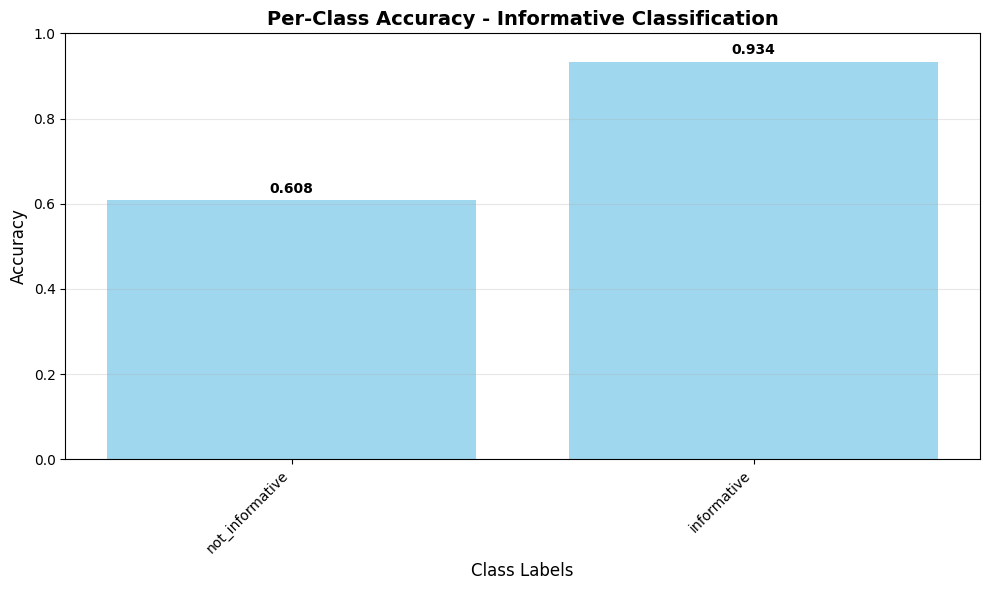


SUMMARY STATISTICS
Overall Test Accuracy: 0.8426
Best Performing Class: informative (0.9336)
Worst Performing Class: not_informative (0.6080)
Average Per-Class Accuracy: 0.7708
Standard Deviation: 0.1628

CLASS DISTRIBUTION IN TEST SET
not_informative          :  625 samples (27.9%)
informative              : 1612 samples (72.1%)

BINARY CLASSIFICATION METRICS
True Negatives:  380
False Positives: 245
False Negatives: 107
True Positives:  1505

Precision (Informative): 0.8600
Recall (Informative):    0.9336
Specificity:             0.6080
F1-Score:                0.8953


In [16]:
# Confusion Matrix and Detailed Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Function to get predictions for confusion matrix
def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Getting predictions'):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images, input_ids, attention_mask)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

# Get predictions for test set
print("Getting test set predictions...")
test_labels, test_preds = get_predictions(model, test_loader, device)

# Create label mapping for better visualization
label_map = {'not_informative': 0, 'informative': 1}
reverse_label_map = {v: k for k, v in label_map.items()}
class_names = [reverse_label_map[i] for i in range(len(label_map))]

# Create confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detailed classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Per-class accuracy analysis
print("\n" + "="*80)
print("PER-CLASS ACCURACY ANALYSIS")
print("="*80)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
for i, (class_name, accuracy) in enumerate(zip(class_names, class_accuracies)):
    total_samples = cm.sum(axis=1)[i]
    correct_samples = cm.diagonal()[i]
    print(f"{class_name:25}: {accuracy:.4f} ({correct_samples}/{total_samples} samples)")

# Plot per-class accuracy
plt.figure(figsize=(10, 6))
plt.bar(range(len(class_names)), class_accuracies, color='skyblue', alpha=0.8)
plt.xlabel('Class Labels', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy - Informative Classification', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on top of bars
for i, accuracy in enumerate(class_accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
overall_accuracy = np.trace(cm) / np.sum(cm)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")
print(f"Best Performing Class: {class_names[np.argmax(class_accuracies)]} ({class_accuracies.max():.4f})")
print(f"Worst Performing Class: {class_names[np.argmin(class_accuracies)]} ({class_accuracies.min():.4f})")
print(f"Average Per-Class Accuracy: {class_accuracies.mean():.4f}")
print(f"Standard Deviation: {class_accuracies.std():.4f}")

# Class distribution analysis
print("\n" + "="*80)
print("CLASS DISTRIBUTION IN TEST SET")
print("="*80)
unique_test, counts_test = np.unique(test_labels, return_counts=True)
for label_idx, count in zip(unique_test, counts_test):
    class_name = reverse_label_map[label_idx]
    percentage = count / len(test_labels) * 100
    print(f"{class_name:25}: {count:4d} samples ({percentage:.1f}%)")

# Additional metrics for binary classification
print("\n" + "="*80)
print("BINARY CLASSIFICATION METRICS")
print("="*80)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Precision (Informative): {precision:.4f}")
print(f"Recall (Informative):    {recall:.4f}")
print(f"Specificity:             {specificity:.4f}")
print(f"F1-Score:                {f1_score:.4f}")

  warnings.warn(
                                                                  


1) Main Performance Table


,Accuracy,Precision_macro,Recall_macro,F1_macro
Full Model,0.8426,0.8201,0.7708,0.7894


  warnings.warn(
  warnings.warn(
  warnings.warn(
                                                                        


2) Ablation Table


...


5) Efficiency Table


,Total_params,Trainable_params,Approx_model_size_MB,Latency_ms_per_sample,Throughput_samples_per_sec
0,139566146,139566146,532.4026,19.0497,52.4944


  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
                                                                  


6) Robustness Table


,Noise_std,Accuracy,F1_macro
0,0.00,0.8426,0.7894
1,0.01,0.8435,0.7906
2,0.03,0.8426,0.7889
3,0.05,0.8418,0.7879


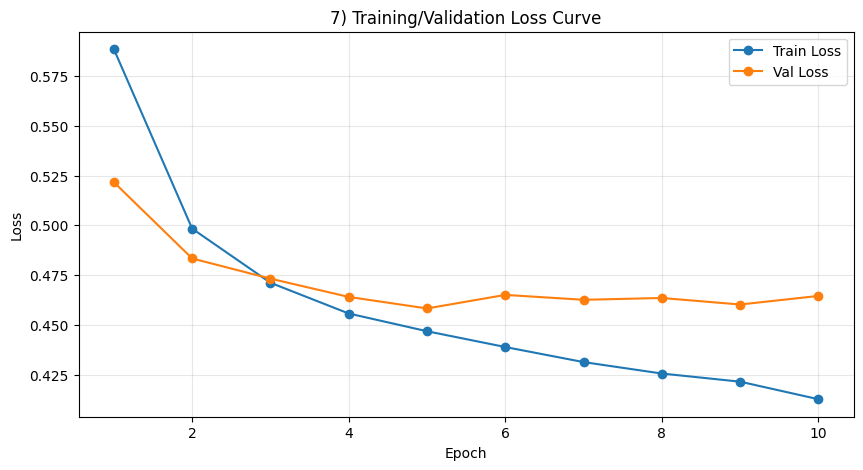

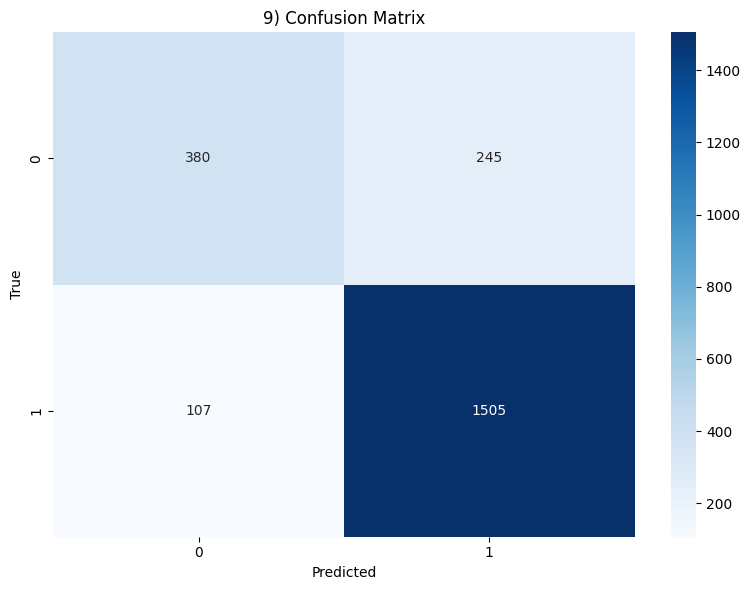

/tmp/ipykernel_55/2684354134.py:194: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Modality', y='Importance (Acc drop from full)', palette='viridis')


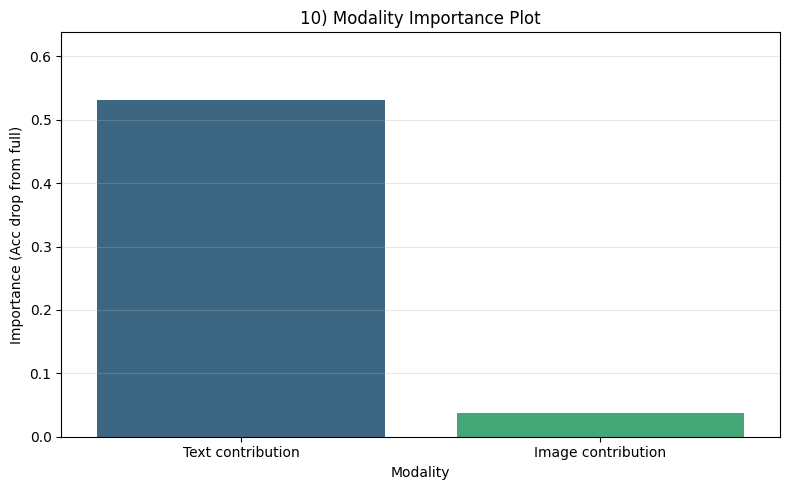

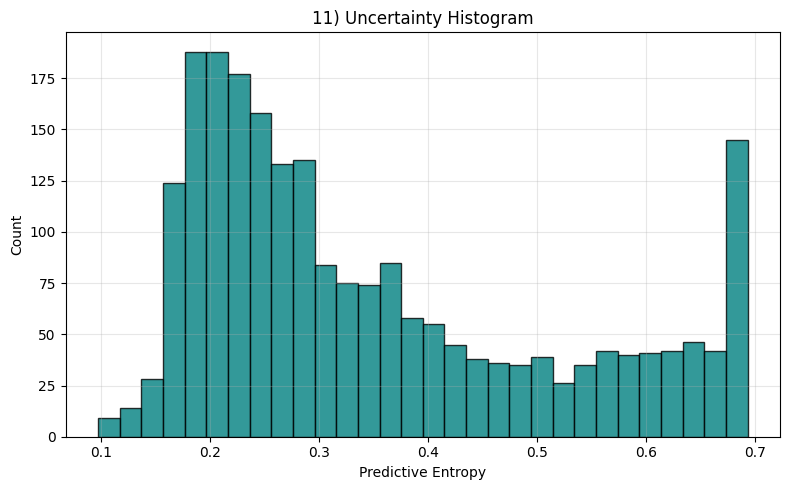

/tmp/ipykernel_55/2684354134.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_acc = c_df.groupby('bin').agg(


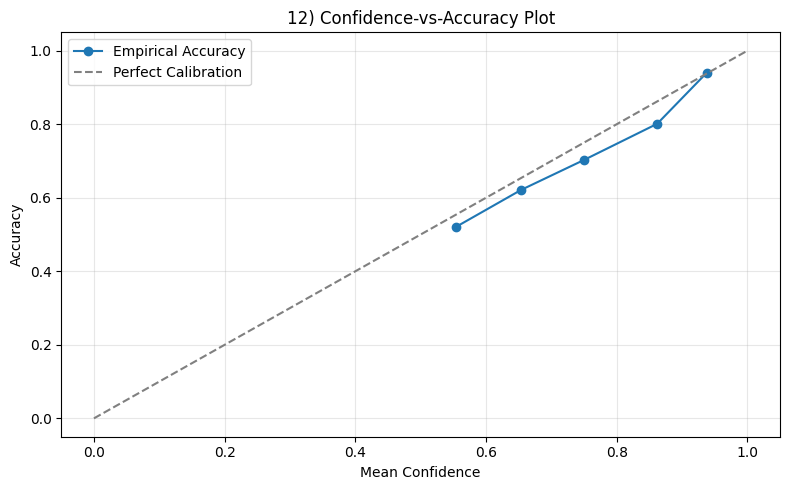

13) Attention Heatmap could not be generated: BertTokenizer has no attribute encode_plus

Results section completed.


In [17]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, f1_score
    )


def _forward_with_mode(model, images, input_ids, attention_mask, mode='full'):
    if mode == 'text_only':
        images = torch.zeros_like(images)
    elif mode == 'image_only':
        input_ids = torch.zeros_like(input_ids)
        attention_mask = torch.zeros_like(attention_mask)
    return model(images, input_ids, attention_mask)


@torch.no_grad()
def collect_predictions(model, loader, device, mode='full', max_batches=None, image_noise_std=0.0):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for b_idx, batch in enumerate(tqdm(loader, desc=f'Collecting ({mode})', leave=False), 1):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        if image_noise_std > 0:
            noise = torch.randn_like(images) * image_noise_std
            images = torch.clamp(images + noise, -3.0, 3.0)

        outputs = _forward_with_mode(model, images, input_ids, attention_mask, mode=mode)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        if max_batches is not None and b_idx >= max_batches:
            break

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def compute_summary_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_macro': p,
        'Recall_macro': r,
        'F1_macro': f1
    }


def print_table(title, df):
    print(f"\n{'=' * 90}\n{title}\n{'=' * 90}")
    display(df)


# 1) Main performance table (Full model on test set)
y_true_full, y_pred_full, y_prob_full = collect_predictions(model, test_loader, device, mode='full')
main_metrics = compute_summary_metrics(y_true_full, y_pred_full)
main_perf_df = pd.DataFrame([main_metrics], index=['Full Model'])
print_table('1) Main Performance Table', main_perf_df.round(4))


# 2) Ablation table
ablation_rows = []
for mode_name, mode in [('Full', 'full'), ('Text only', 'text_only'), ('Image only', 'image_only')]:
    y_t, y_p, _ = collect_predictions(model, test_loader, device, mode=mode)
    m = compute_summary_metrics(y_t, y_p)
    m['Setting'] = mode_name
    ablation_rows.append(m)
ablation_df = pd.DataFrame(ablation_rows).set_index('Setting')
print_table('2) Ablation Table', ablation_df.round(4))


# 3) Per-class metrics table
per_class_report = classification_report(
    y_true_full, y_pred_full, output_dict=True, zero_division=0
    )
per_class_df = pd.DataFrame(per_class_report).T
per_class_df = per_class_df[~per_class_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
print_table('3) Per-Class Metrics Table', per_class_df.round(4))


# 4) Uncertainty-performance table
eps = 1e-12
uncertainty = -np.sum(y_prob_full * np.log(y_prob_full + eps), axis=1)
confidence = np.max(y_prob_full, axis=1)
correct = (y_true_full == y_pred_full).astype(int)
u_df = pd.DataFrame({'uncertainty': uncertainty, 'correct': correct})
u_df['bin'] = pd.qcut(u_df['uncertainty'], q=5, duplicates='drop')
uncert_perf_df = u_df.groupby('bin').agg(
    Samples=('correct', 'count'),
    Accuracy=('correct', 'mean'),
    Uncertainty_mean=('uncertainty', 'mean')
).reset_index()
print_table('4) Uncertainty-Performance Table', uncert_perf_df.round(4))


# 5) Efficiency table (approximate benchmark on subset)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = (n_params * 4) / (1024 ** 2)

bench_batches = 20
start = time.time()
_ = collect_predictions(model, test_loader, device, mode='full', max_batches=bench_batches)
elapsed = time.time() - start
samples_bench = min(len(test_dataset), bench_batches * test_loader.batch_size)
ms_per_sample = (elapsed * 1000.0) / max(samples_bench, 1)
throughput = samples_bench / max(elapsed, 1e-9)

efficiency_df = pd.DataFrame([{
    'Total_params': n_params,
    'Trainable_params': n_trainable,
    'Approx_model_size_MB': model_size_mb,
    'Latency_ms_per_sample': ms_per_sample,
    'Throughput_samples_per_sec': throughput
}])
print_table('5) Efficiency Table', efficiency_df.round(4))


# 6) Robustness table (image noise stress test)
robust_rows = []
for sigma in [0.00, 0.01, 0.03, 0.05]:
    y_t, y_p, _ = collect_predictions(
        model, test_loader, device, mode='full', image_noise_std=sigma
    )
    robust_rows.append({
        'Noise_std': sigma,
        'Accuracy': accuracy_score(y_t, y_p),
        'F1_macro': f1_score(y_t, y_p, average='macro')
    })
robustness_df = pd.DataFrame(robust_rows)
print_table('6) Robustness Table', robustness_df.round(4))


# 7) Training/validation loss curve
if 'train_losses' in globals() and 'val_losses' in globals() and len(train_losses) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train Loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Val Loss')
    plt.title('7) Training/Validation Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# 8) Training/validation F1 curve
if 'train_f1s' in globals() and 'val_f1s' in globals() and len(train_f1s) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_f1s) + 1), train_f1s, marker='o', label='Train F1 (macro)')
    plt.plot(range(1, len(val_f1s) + 1), val_f1s, marker='o', label='Val F1 (macro)')
    plt.title('8) Training/Validation F1 Curve')
    plt.xlabel('Epoch')
    plt.ylabel('F1-score')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# 9) Confusion matrix
cm = confusion_matrix(y_true_full, y_pred_full)
class_names = sorted(list(set(y_true_full.tolist())))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('9) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# 10) Modality importance plots
full_acc = ablation_df.loc['Full', 'Accuracy']
text_only_acc = ablation_df.loc['Text only', 'Accuracy']
image_only_acc = ablation_df.loc['Image only', 'Accuracy']
importance_df = pd.DataFrame({
    'Modality': ['Text contribution', 'Image contribution'],
    'Importance (Acc drop from full)': [
        max(full_acc - image_only_acc, 0),
        max(full_acc - text_only_acc, 0)
    ]
})
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Modality', y='Importance (Acc drop from full)', palette='viridis')
plt.title('10) Modality Importance Plot')
plt.ylim(0, max(importance_df['Importance (Acc drop from full)'].max() * 1.2, 0.05))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 11) Uncertainty histogram
plt.figure(figsize=(8, 5))
plt.hist(uncertainty, bins=30, color='teal', alpha=0.8, edgecolor='black')
plt.title('11) Uncertainty Histogram')
plt.xlabel('Predictive Entropy')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 12) Confidence-vs-accuracy plot
c_df = pd.DataFrame({'confidence': confidence, 'correct': correct})
c_df['bin'] = pd.cut(c_df['confidence'], bins=np.linspace(0, 1, 11), include_lowest=True)
conf_acc = c_df.groupby('bin').agg(
    Accuracy=('correct', 'mean'),
    MeanConfidence=('confidence', 'mean'),
    Samples=('correct', 'count')
).reset_index()
plt.figure(figsize=(8, 5))
plt.plot(conf_acc['MeanConfidence'], conf_acc['Accuracy'], marker='o', label='Empirical Accuracy')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')
plt.title('12) Confidence-vs-Accuracy Plot')
plt.xlabel('Mean Confidence')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 13) Attention heatmap (BERT final layer CLS attention over tokens)
try:
    sample_text = str(test_df.iloc[0]['tweet_text'])
    enc = tokenizer.encode_plus(
        sample_text,
        add_special_tokens=True,
        max_length=64,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    in_ids = enc['input_ids'].to(device)
    attn_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        attn_out = model.text_encoder(
            input_ids=in_ids, attention_mask=attn_mask, output_attentions=True
        )

    # transformers v2.x: attentions are usually last item in output tuple
    attentions = attn_out[-1] if isinstance(attn_out, (tuple, list)) else None
    if attentions is not None and len(attentions) > 0:
        last_layer = attentions[-1][0]  # [heads, seq, seq]
        cls_to_tokens = last_layer[:, 0, :].mean(dim=0).cpu().numpy()
        tokens = tokenizer.convert_ids_to_tokens(in_ids[0].cpu().numpy())

        valid_len = int(attn_mask[0].sum().item())
        cls_to_tokens = cls_to_tokens[:valid_len]
        tokens = tokens[:valid_len]

        plt.figure(figsize=(min(18, 0.35 * len(tokens) + 4), 3.5))
        sns.heatmap(
            cls_to_tokens.reshape(1, -1),
            cmap='magma',
            cbar=True,
            xticklabels=tokens,
            yticklabels=['CLS attention']
        )
        plt.title('13) Attention Heatmap (BERT CLS -> Tokens)')
        plt.xticks(rotation=60, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print('13) Attention Heatmap: attentions are not available from this model output.')
except Exception as e:
    print(f'13) Attention Heatmap could not be generated: {e}')

print('\nResults section completed.')